   ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  Has_Garden  Has_Pool  Garage_Size  Location_Score  Distance_to_Center          Price
0   1   143.635030             1              3           3        1967           1         1           48        8.297631            5.935734  602134.816747
1   2   287.678577             1              2           1        1949           0         1           37        6.061466           10.827392  591425.135386
2   3   232.998485             1              3           2        1923           1         0           14        2.911442            6.904599  464478.696880
3   4   199.664621             5              2           2        1918           0         0           17        2.070949            8.284019  583105.655996
4   5    89.004660             4              3           3        1999           1         0           34        1.523278           14.648277  619879.142523
5   6    88.998630             5              3     

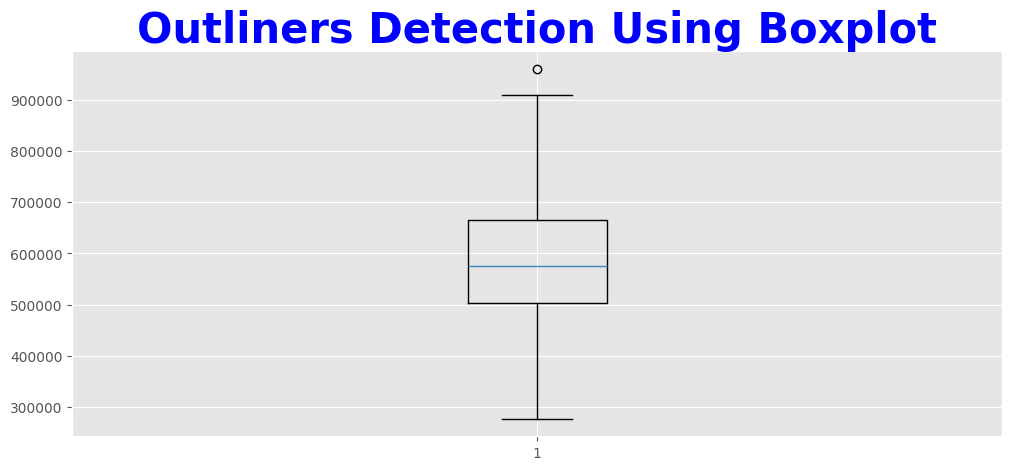

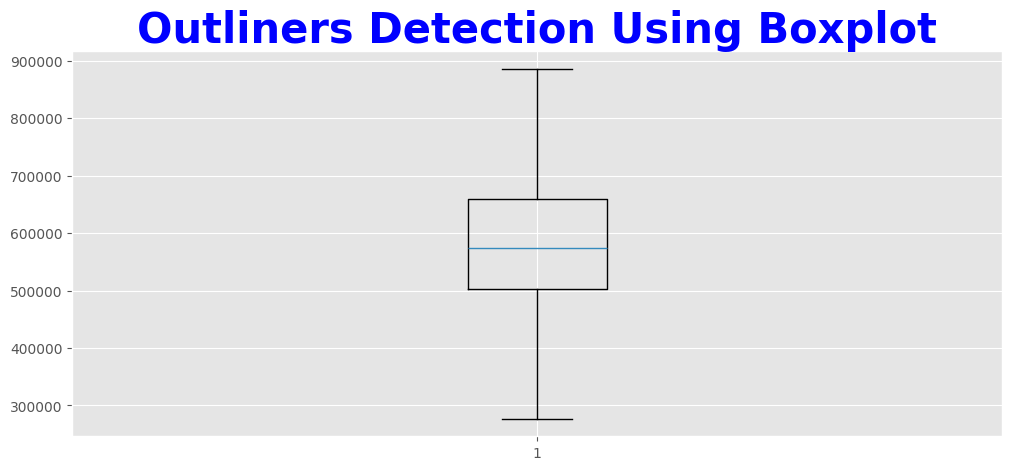

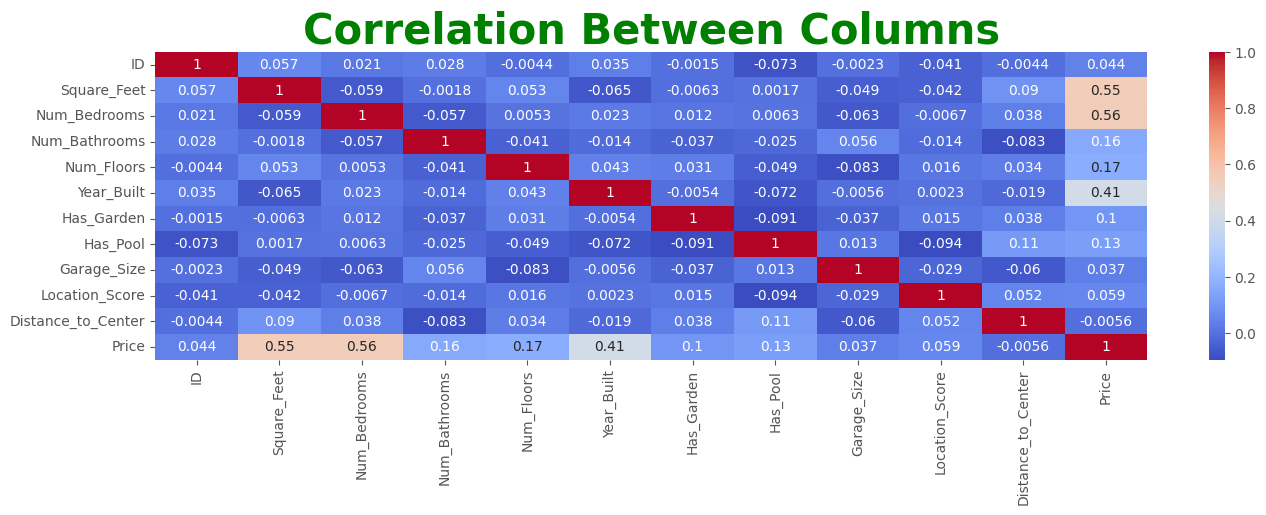

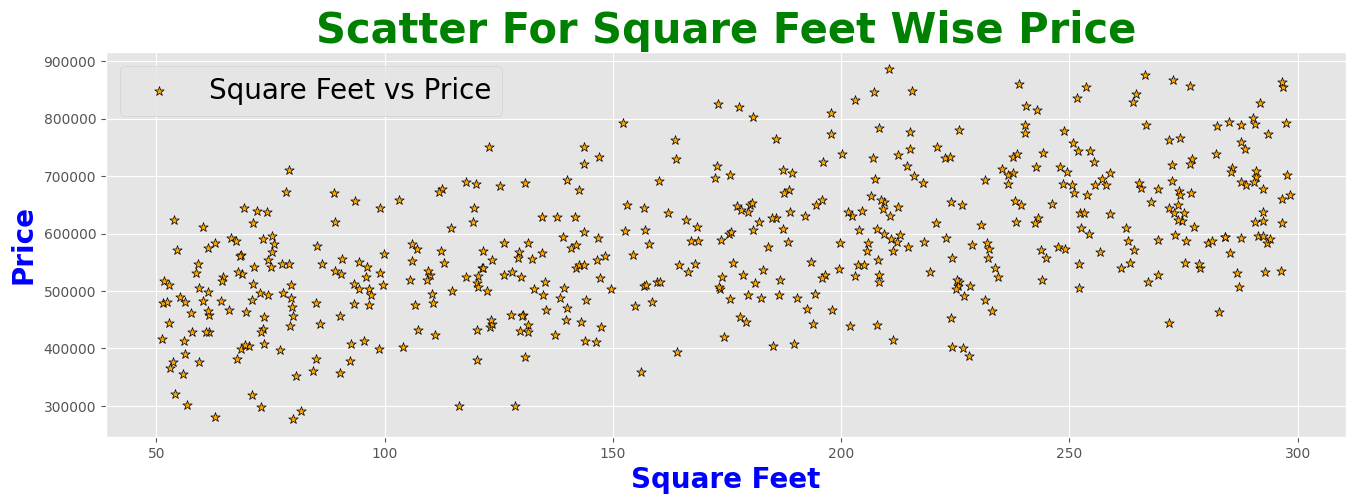

   ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  Has_Garden  Has_Pool  Garage_Size  Location_Score  Distance_to_Center          Price  House_Details  House_Age
0   1   143.635030             1              3           3        1967           1         1           48        8.297631            5.935734  602134.816747       4.002321         59
1   2   287.678577             1              2           1        1949           0         1           37        6.061466           10.827392  591425.135386       3.003476         77
2   3   232.998485             1              3           2        1923           1         0           14        2.911442            6.904599  464478.696880       4.000000        103
3   4   199.664621             5              2           2        1918           0         0           17        2.070949            8.284019  583105.655996       7.000000        108
4   5    89.004660             4              3           3        1999         

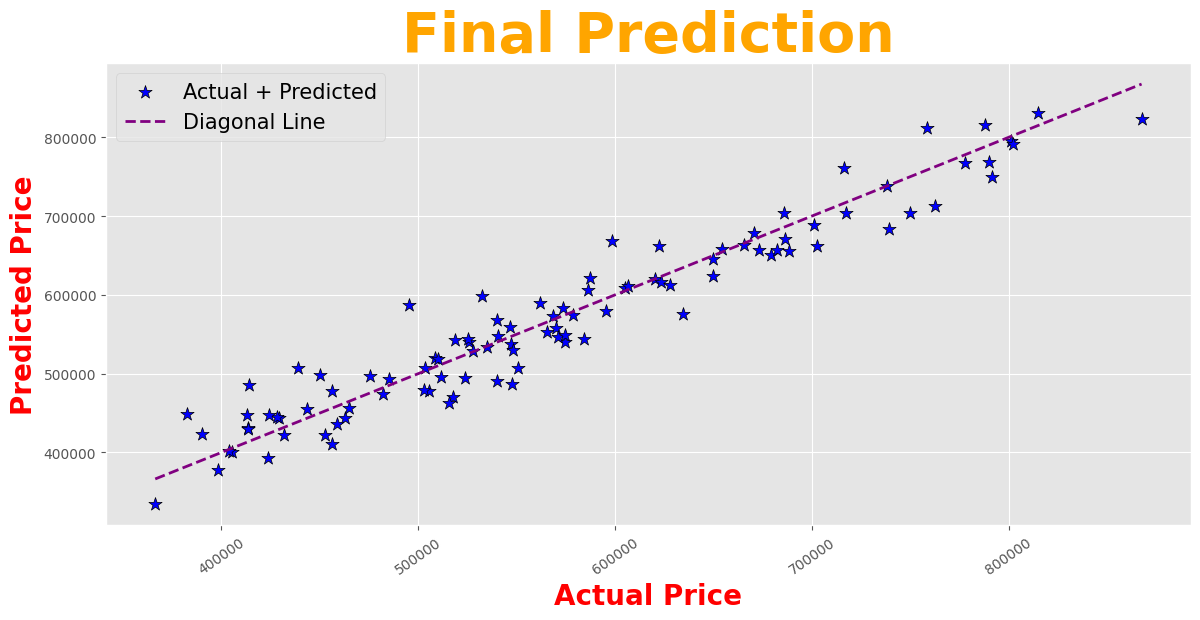

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.width',None)
pd.set_option('display.expand_frame_repr',False)

JP=pd.read_csv("House_Price.csv")

print(JP.head(10))

# print(JP.isna().sum())
# AC=JP[JP.duplicated()]
# print(AC)

# print(JP.columns)

plt.figure(figsize=(12,5))
plt.boxplot(JP['Price'])
plt.title("Outliners Detection Using Boxplot",fontsize=30,fontweight="bold",color='Blue')
plt.show()

Q1=JP['Price'].quantile(0.25)
Q3=JP['Price'].quantile(0.75)

IQR=Q3 - Q1

lower=Q1 - 1.5 * IQR
upper=Q3 + 1.45 * IQR

JP = JP [(JP['Price'] >= lower) & (JP['Price'] <= upper)]


plt.figure(figsize=(12,5))
plt.boxplot(JP['Price'])
plt.title("After Removing Outliners",fontsize=30,fontweight="bold",color='Blue')
plt.show()

plt.figure(figsize=(16,4))
sns.heatmap(JP.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Between Columns",fontweight='bold',fontsize=30,color='Green')
plt.show()

plt.figure(figsize=(16,5))
plt.scatter(JP['Square_Feet'],JP['Price'],marker="*",s=50,color='orange',edgecolor='black',label='Square Feet vs Price')
plt.title("Scatter For Square Feet Wise Price",fontweight='bold',color='green',fontsize=30)
plt.xlabel("Square Feet",color='blue',fontsize=20,fontweight='bold')
plt.ylabel("Price",color='blue',fontsize=20,fontweight='bold')
plt.legend(loc='upper left',fontsize=20)
plt.show()

JP['House_Details']=JP['Num_Bedrooms'] + JP['Num_Bathrooms'] + JP['Has_Pool'] / JP['Num_Floors'] / JP['Square_Feet']
JP['House_Age']=2026 - JP['Year_Built']
print(JP.head(10))

x=JP[['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors',
       'Year_Built', 'Has_Pool','House_Details','House_Age']]
y=JP['Price']


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model  import LinearRegression

scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


model=LinearRegression()
score=cross_val_score(model,x_scaled,y,cv=5,scoring="r2")

print("Cross Validation Score",score)
print("Average CVS",score.mean())

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , r2_score

x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=34)

model.fit(x_train,y_train)
Y_Pred=model.predict(x_test)

Train_R2=model.score(x_train,y_train)
Test_R2=model.score(x_test,y_test)

print("Train R2",Train_R2)
print("Test R2",Test_R2)

print("MAE Of LinearRegression",mean_absolute_error(y_test,Y_Pred))
print("r2 Of LinearRegression",r2_score(y_test,Y_Pred))



# from sklearn.ensemble import RandomForestRegressor 

# model=RandomForestRegressor()

# model.fit(x_train,y_train)
# Y_Pred=model.predict(x_test)

# print("MAE Of RandomForestRegressor",mean_absolute_error(y_test,Y_Pred))
# print("r2 Score",r2_score(y_test,Y_Pred))

plt.figure(figsize=(14,6))
plt.scatter(y_test,Y_Pred,marker="*",s=100,color='blue',edgecolor='black',label='Actual + Predicted' )
plt.plot( [y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] ,linewidth=2,color='purple',linestyle="--",label='Diagonal Line')
plt.xlabel("Actual Price",fontweight='bold',fontsize=20,color='red')
plt.ylabel("Predicted Price",fontweight='bold',fontsize=20,color='red')
plt.title("Final Prediction",fontsize=40,fontweight='bold',color='orange')
plt.xticks(rotation=35)
plt.legend(loc='upper left',fontsize=15)
plt.show()